In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [2]:
train_directory = "../data/train"
test_directory = "../data/test"

image_size = (224, 224)
batch_size = 32

class_names = ["ok_front", "def_front"]

print("Training directory:", train_directory)
print("Testing directory:", test_directory)

Training directory: ../data/train
Testing directory: ../data/test


In [8]:
import os

print("Python is currently here:")
print(os.getcwd())

print("\nDoes data folder exist?")
print(os.path.exists("data"))

print("\nDoes ../data folder exist?")
print(os.path.exists("../data"))

Python is currently here:
c:\Users\Varsha\Desktop\casting-quality-inspection-project\notebooks

Does data folder exist?
False

Does ../data folder exist?
True


In [10]:
import os

print("Train - Defective:", len(os.listdir("../data/train/def_front")))
print("Train - Good:", len(os.listdir("../data/train/ok_front")))
print("Test - Defective:", len(os.listdir("../data/test/def_front")))
print("Test - Good:", len(os.listdir("../data/test/ok_front")))

Train - Defective: 3758
Train - Good: 2875
Test - Defective: 453
Test - Good: 262


In [11]:
import tensorflow as tf

train_directory = "../data/train"

class_names = ["ok_front", "def_front"]

image_size = (224, 224)
batch_size = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_directory,
    class_names=class_names,
    validation_split=0.20,
    subset="training",
    seed=42,
    image_size=image_size,
    batch_size=batch_size,
    label_mode="binary"
)

print("Training dataset loaded successfully!")

Found 6633 files belonging to 2 classes.
Using 5307 files for training.
Training dataset loaded successfully!


In [12]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    train_directory,
    class_names=class_names,
    validation_split=0.20,
    subset="validation",
    seed=42,
    image_size=image_size,
    batch_size=batch_size,
    label_mode="binary"
)

print("Validation dataset loaded successfully!")

Found 6633 files belonging to 2 classes.
Using 1326 files for validation.
Validation dataset loaded successfully!


In [13]:
test_directory = "../data/test"

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_directory,
    class_names=class_names,
    image_size=image_size,
    batch_size=batch_size,
    label_mode="binary",
    shuffle=False
)

print("Test dataset loaded successfully!")

Found 715 files belonging to 2 classes.
Test dataset loaded successfully!


In [14]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])

model.summary()

c:\Users\Varsha\Desktop\casting-quality-inspection-project\venv\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("CNN model compiled successfully!")

CNN model compiled successfully!


In [16]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10
)

Epoch 1/10


c:\Users\Varsha\Desktop\casting-quality-inspection-project\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


166/166 ━━━━━━━━━━━━━━━━━━━━ 182s 1s/step - accuracy: 0.6866 - loss: 0.5881 - val_accuracy: 0.8431 - val_loss: 0.3534
Epoch 2/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 169s 1s/step - accuracy: 0.8881 - loss: 0.2617 - val_accuracy: 0.9608 - val_loss: 0.1192
Epoch 3/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - accuracy: 0.9395 - loss: 0.1519 - val_accuracy: 0.9781 - val_loss: 0.1067
Epoch 4/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - accuracy: 0.9691 - loss: 0.0902 - val_accuracy: 0.9382 - val_loss: 0.1403
Epoch 5/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 165s 991ms/step - accuracy: 0.9761 - loss: 0.0745 - val_accuracy: 0.9766 - val_loss: 0.0538
Epoch 6/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 165s 994ms/step - accuracy: 0.9774 - loss: 0.0592 - val_accuracy: 0.9894 - val_loss: 0.0364
Epoch 7/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - accuracy: 0.9868 - loss: 0.0411 - val_accuracy: 0.9781 - val_loss: 0.0546
Epoch 8/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 161s 970ms/step - accuracy: 0.9861 - loss: 0.0425 - val_accura

In [18]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 299ms/step - accuracy: 0.9804 - loss: 0.0433
Test Loss: 0.04328080639243126
Test Accuracy: 0.9804195761680603


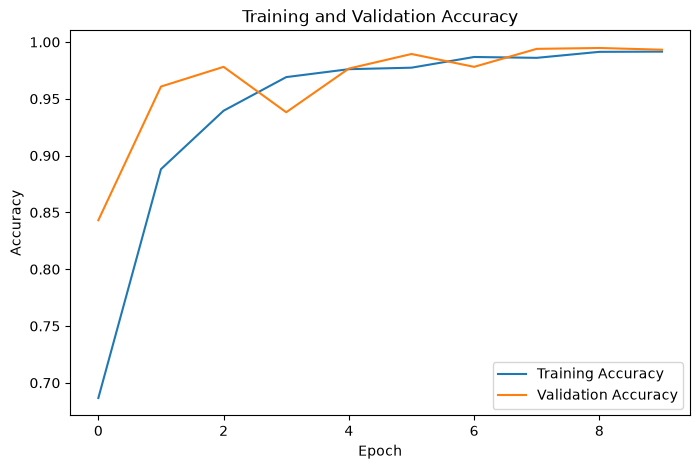

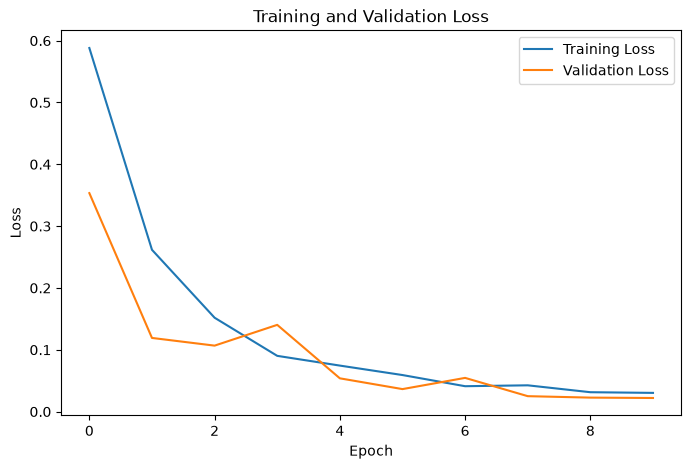

In [19]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss graph
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [20]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Get predictions
y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)
    
    y_true.extend(labels.numpy().flatten())
    y_pred.extend((predictions > 0.5).astype(int).flatten())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

# Precision, Recall and F1-score
print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=["ok_front", "def_front"]
))

Confusion Matrix:
[[262   0]
 [ 14 439]]

Classification Report:
              precision    recall  f1-score   support

    ok_front       0.95      1.00      0.97       262
   def_front       1.00      0.97      0.98       453

    accuracy                           0.98       715
   macro avg       0.97      0.98      0.98       715
weighted avg       0.98      0.98      0.98       715



In [21]:
model.save("../models/casting_defect_model.keras")

print("Model saved successfully!")

Model saved successfully!


Prediction: OK / ACCEPTABLE
Prediction Score: 0.0012942462


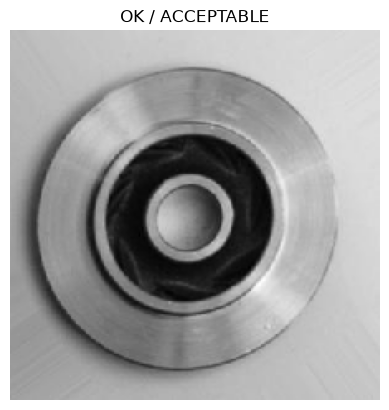

In [22]:
import tensorflow as tf
import matplotlib.pyplot as plt

image_path = "../sample_images/test_casting.jpeg"

img = tf.keras.utils.load_img(
    image_path,
    target_size=(224, 224)
)

img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)

prediction = model.predict(img_array, verbose=0)[0][0]

if prediction >= 0.5:
    result = "DEFECTIVE"
else:
    result = "OK / ACCEPTABLE"

print("Prediction:", result)
print("Prediction Score:", prediction)

plt.imshow(img)
plt.axis("off")
plt.title(result)
plt.show()

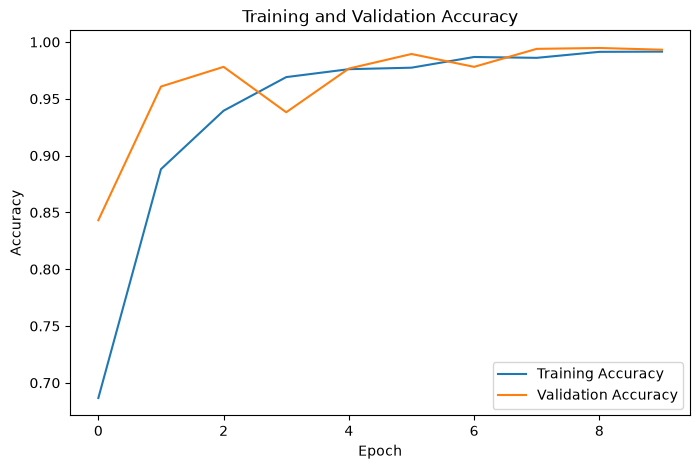

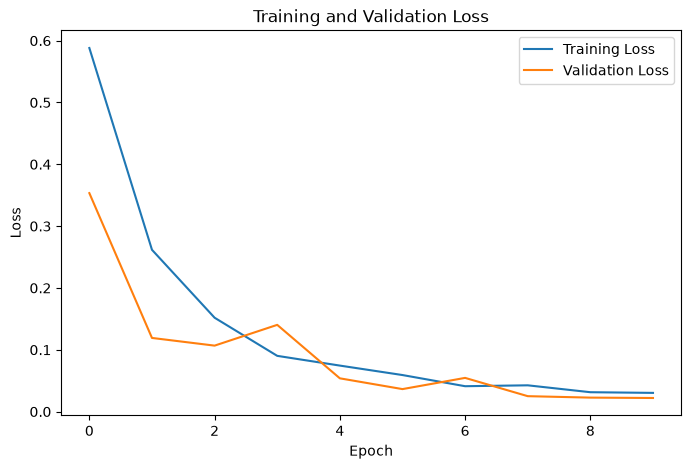

Graphs saved successfully!


In [23]:
import matplotlib.pyplot as plt

# Save Accuracy graph
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.savefig("../reports/accuracy_graph.png")
plt.show()

# Save Loss graph
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig("../reports/loss_graph.png")
plt.show()

print("Graphs saved successfully!")

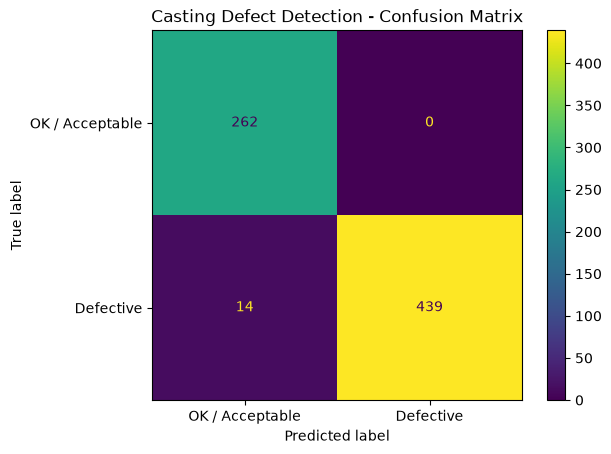

Confusion matrix saved successfully!


In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["OK / Acceptable", "Defective"]
)

disp.plot()
plt.title("Casting Defect Detection - Confusion Matrix")
plt.savefig("../reports/confusion_matrix.png")
plt.show()

print("Confusion matrix saved successfully!")

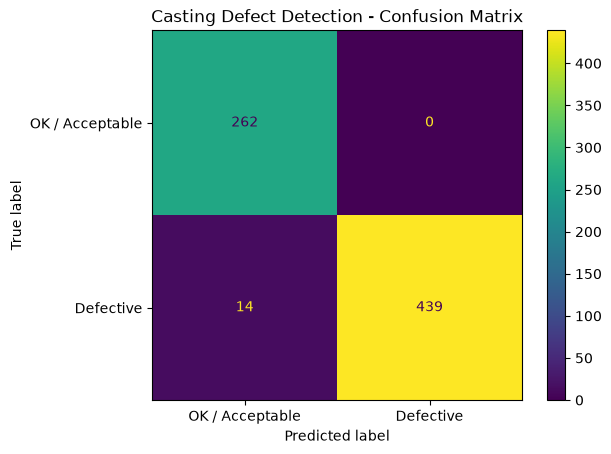

Confusion matrix saved successfully!


In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["OK / Acceptable", "Defective"]
)

disp.plot()
plt.title("Casting Defect Detection - Confusion Matrix")
plt.savefig("../reports/confusion_matrix.png")
plt.show()

print("Confusion matrix saved successfully!")

In [26]:
print("FINAL MODEL PERFORMANCE")
print("------------------------")

print("Test Accuracy :", test_accuracy)
print("Test Loss     :", test_loss)

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=["OK / Acceptable", "Defective"]
))

FINAL MODEL PERFORMANCE
------------------------
Test Accuracy : 0.9804195761680603
Test Loss     : 0.04328080639243126

Classification Report:
                 precision    recall  f1-score   support

OK / Acceptable       0.95      1.00      0.97       262
      Defective       1.00      0.97      0.98       453

       accuracy                           0.98       715
      macro avg       0.97      0.98      0.98       715
   weighted avg       0.98      0.98      0.98       715

